<a href="https://colab.research.google.com/github/succSeeded/dl-2025/blob/main/hws/week10_vae/seminar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
z_logits = torch.randn(2, 3)  # dummy encoder output
print("We want these probabilities:")
print(torch.softmax(z_logits, dim=-1))

# gumbel-max trick
noise = -torch.log(-(torch.log(torch.rand_like(z_logits))))
argmax_1hot = F.one_hot((z_logits + noise).argmax(-1),
                           num_classes=z_logits.shape[-1])
print("Gumbel-max-onehot\n", argmax_1hot)


We want these probabilities:
tensor([[0.6991, 0.0979, 0.2030],
        [0.6079, 0.2122, 0.1798]])
Gumbel-max-onehot
 tensor([[1, 0, 0],
        [0, 1, 0]])


In [ ]:
results = []
for i in range(100000):
  noise = -torch.log(-(torch.log(torch.rand_like(z_logits))))
  argmax_1hot = F.one_hot((z_logits + noise).argmax(-1),
                           num_classes=z_logits.shape[-1])
  results.append(argmax_1hot)

print(sum(results) / len(results)) # should be the same as softmax above

tensor([[0.6974, 0.0994, 0.2032],
        [0.6115, 0.2114, 0.1771]])


--2025-11-14 18:01:39--  https://raw.githubusercontent.com/yandexdataschool/Practical_DL/refs/heads/fall25/week02_autodiff/notmnist.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1788 (1.7K) [text/plain]
Saving to: ‘notmnist.py.2’

notmnist.py.2       100%[===================>]   1.75K  --.-KB/s    in 0s      

2025-11-14 18:01:39 (31.5 MB/s) - ‘notmnist.py.2’ saved [1788/1788]

Parsing...
found broken img: ./notMNIST_small/F/Q3Jvc3NvdmVyIEJvbGRPYmxpcXVlLnR0Zg==.png [it's ok if <10 images are broken]
found broken img: ./notMNIST_small/A/RGVtb2NyYXRpY2FCb2xkT2xkc3R5bGUgQm9sZC50dGY=.png [it's ok if <10 images are broken]
Done


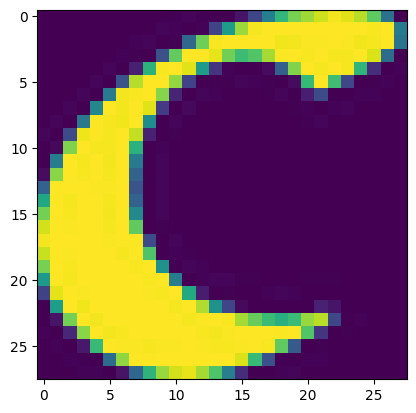

In [ ]:
!wget https://raw.githubusercontent.com/yandexdataschool/Practical_DL/refs/heads/fall25/week02_autodiff/notmnist.py
import matplotlib.pyplot as plt
%matplotlib inline
from notmnist import load_notmnist
X, _, _, _ = load_notmnist(test_size=0.00001)
X = torch.as_tensor(X.reshape(len(X), -1))
plt.imshow(X[0].view(28, 28))

In [ ]:
num_codes = 8
nbits_per_code = 8
encoder = nn.Sequential(
    nn.Linear(X.shape[1], 256), nn.GELU(),
    nn.Linear(256, num_codes * 2**nbits_per_code),
)
decoder = nn.Sequential(
    nn.Linear(num_codes * 2**nbits_per_code, 256),
    nn.GELU(), nn.Linear(256, X.shape[1])
)
opt = torch.optim.Adam(
    nn.ModuleList([encoder, decoder]).parameters())

In [ ]:
for i in range(1000):
  x_batch = X[torch.randint(0, len(X), size=(256,))]
  z = F.gumbel_softmax(
    encoder(x_batch).reshape(
        len(x_batch), num_codes, 2**nbits_per_code),
    tau=0.1, hard=True
    ).flatten(1, 2)
  loss = F.mse_loss(decoder(z), x_batch)
  opt.zero_grad()
  loss.backward()
  opt.step()
  if i % 50 == 0:
    print(loss.item())

0.9832820296287537
0.6576465964317322
0.5421354174613953
0.4461132884025574
0.44617003202438354
0.388162225484848
0.40376749634742737
0.35135114192962646
0.3211348056793213
0.3247820734977722
0.33914539217948914
0.3147847056388855
0.3166602551937103
0.30777692794799805
0.3112165927886963
0.27786627411842346
0.2829512059688568
0.29778361320495605
0.27732130885124207
0.2977844178676605


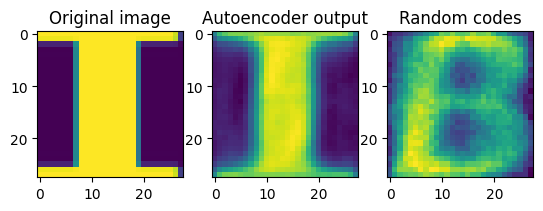

In [ ]:
i = 0
plt.subplot(131)
plt.title("Original image")
plt.imshow(x_batch[i].numpy().reshape(28, 28))
plt.subplot(132)
plt.title("Autoencoder output")
plt.imshow(decoder(z)[i].detach().numpy().reshape(28, 28))
plt.subplot(133)
plt.title("Random codes")
z_alt = F.one_hot(torch.tensor([12,  31,  15, 4, 52, 192,  142,  0]), 2**nbits_per_code).flatten().float()
plt.imshow(decoder(z_alt).detach().numpy().reshape(28, 28))